# Basic GP Regression

Your first Gaussian Process model in LightGP. We will:

1. Generate noisy synthetic data
2. Fit a GP with an RBF kernel
3. Visualize predictions with uncertainty bands
4. Improve the fit by optimizing hyperparameters
5. Compare different kernel smoothnesses

In [1]:
import os
import sys

# Make the locally-built lightgp importable. Real users install via 'pip install lightgp'.
sys.path.insert(0, os.path.abspath(os.path.join("..", "..", "..", "python")))

import numpy as np
import matplotlib.pyplot as plt
import lightgp as gp

rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (8, 3.5), "figure.dpi": 90})

## Generate noisy data

Sample 40 points from `y = sin(x) + noise`.

In [2]:
X = np.sort(rng.uniform(-3, 3, 40)).reshape(-1, 1).astype(np.float32)
y = (np.sin(X[:, 0]) + 0.15 * rng.standard_normal(40)).astype(np.float32)
X_test = np.linspace(-4, 4, 250).reshape(-1, 1).astype(np.float32)
print("X:", X.shape, X.dtype, "  y:", y.shape, y.dtype)

X: (40, 1) float32   y: (40,) float32


## Fit a GP

`GPExact(kernel)` is the simplest entry point. We start with an RBF kernel
at a deliberately bad initial length scale so the un-optimized fit looks rough.

In [3]:
model = gp.GPExact(gp.RBF(length_scale=0.3), noise_var=0.1)
model.fit(X, y)
pred_before = model.predict(X_test)
ll_before = model.log_marginal_likelihood()
print(f"log marginal likelihood before optimize: {ll_before:.3f}")

log marginal likelihood before optimize: -20.182


## Optimize the hyperparameters

LightGP uses Adam on the log-hyperparameters to maximize the log marginal likelihood.

In [4]:
model.optimize(steps=80)
pred_after = model.predict(X_test)
ll_after = model.log_marginal_likelihood()
print(f"log marginal likelihood after optimize:  {ll_after:.3f}")
print(f"improvement: {ll_after - ll_before:+.3f}")

log marginal likelihood after optimize:  4.990
improvement: +25.172


## Plot before vs after

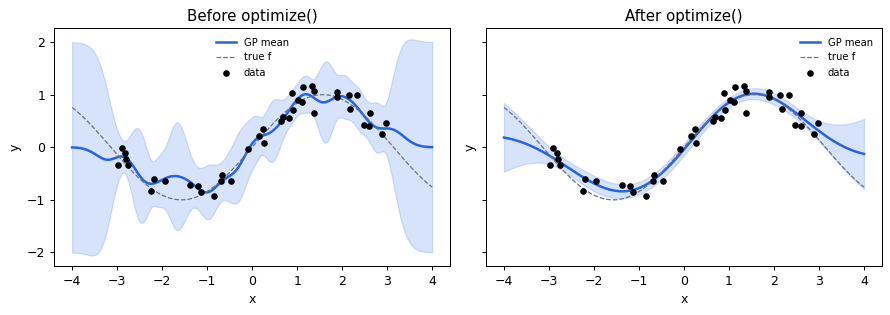

In [5]:
def plot_gp(ax, X, y, X_test, pred, title):
    mu, sd = pred["mean"], np.sqrt(np.maximum(pred["var"], 0))
    ax.fill_between(X_test[:, 0], mu - 2*sd, mu + 2*sd, alpha=0.18, color="#2563EB")
    ax.plot(X_test[:, 0], mu, lw=2, color="#2563EB", label="GP mean")
    ax.plot(X_test[:, 0], np.sin(X_test[:, 0]), "--", color="#6B7280", lw=1, label="true f")
    ax.scatter(X[:, 0], y, c="black", s=18, zorder=5, label="data")
    ax.set_title(title); ax.legend(fontsize=8, frameon=False)
    ax.set_xlabel("x"); ax.set_ylabel("y")

fig, (a, b) = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
plot_gp(a, X, y, X_test, pred_before, "Before optimize()")
plot_gp(b, X, y, X_test, pred_after, "After optimize()")
plt.tight_layout(); plt.show()

## Different kernel smoothnesses

The Matérn-ν family interpolates between rough (ν=½) and smooth (ν=∞ = RBF) fits.

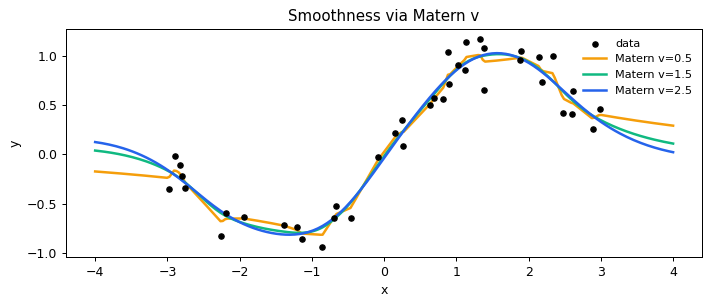

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.scatter(X[:, 0], y, c="black", s=18, zorder=5, label="data")
for nu, color in [(0.5, "#F59E0B"), (1.5, "#10B981"), (2.5, "#2563EB")]:
    m = gp.GPExact(gp.Matern(nu=nu), noise_var=0.1)
    m.fit(X, y); m.optimize(steps=60)
    ax.plot(X_test[:, 0], m.predict(X_test)["mean"], lw=2, color=color, label=f"Matern v={nu}")
ax.legend(fontsize=9, frameon=False); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Smoothness via Matern v")
plt.tight_layout(); plt.show()

## When to use exact GP

`Solver.Cholesky` is **O(N³)**. The rule of thumb on a laptop:

- **N < 5,000**: exact Cholesky is fine and gives the cleanest uncertainty estimates
- **5,000–50,000**: switch to `Solver.CG` (matrix-free on GPU)
- **N > 50,000 and D ≤ 3**: switch to `Solver.SKI` (FFT-accelerated)

The next tutorial shows how to combine kernels for more complex signals.